# ME2 — Personalized two-class wake-word experiment

This notebook trains a fresh `NON_WAKE` / `WAKE_WORD` detector and compares it with the currently installed 32-class wake model. It does not overwrite the command model, the current wake model, or any Raspberry Pi files. The trainer prints every epoch so progress is visible while this cell runs.

**Data limit:** the manifest contains 18 wake rows but only 16 unique decoded recordings, all from `person-01`. A deterministic 10/3/3 recording-level split gives a small same-speaker validation and development holdout. This is a personalized experiment, not evidence of multi-speaker robustness. The Option B holdout was used in prior project work and is exploratory; no claim of a pristine test set is made. No continuous room-audio false-activation-per-hour result is available.

The wake detector is separate from the 31-command classifier. Deployment requires runtime integration, a Codex audit, and on-Pi live testing; this notebook alone does not deploy anything.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

_here = Path.cwd().resolve()
PROJECT_ROOT = next((parent for parent in (_here, *_here.parents) if (parent / 'train_binary_wake.py').is_file()), None)
if PROJECT_ROOT is None:
    candidate = _here / 'AI 231' / 'Dumalaog_ME2 - Tiny Voice Command Model'
    if (candidate / 'train_binary_wake.py').is_file():
        PROJECT_ROOT = candidate
assert PROJECT_ROOT is not None, f'Could not locate project from {_here}'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from train_binary_wake import load_unique_human_wakes, split_wake_groups

rows, groups, manifest_sha256 = load_unique_human_wakes()
train_groups, validation_groups, development_groups = split_wake_groups(groups)
speakers = sorted({group['speaker'] for group in groups})
print(f'Project: {PROJECT_ROOT}')
print(f'Wake manifest rows: {sum(row.get("label") == "wake_word" for row in rows)}')
print(f'Unique decoded recordings: {len(groups)}; split: {len(train_groups)}/{len(validation_groups)}/{len(development_groups)}')
print(f'Speakers: {speakers}')
print(f'Manifest SHA-256: {manifest_sha256}')

DEPLOYED_MODEL_PATHS = [PROJECT_ROOT / 'models' / 'antigrav_optionb_int8.onnx', PROJECT_ROOT / 'models' / 'antigrav_wake32_int8.onnx']
DEPLOYED_MODEL_HASHES = {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in DEPLOYED_MODEL_PATHS}
print('Pre-training deployed-model hashes:', json.dumps(DEPLOYED_MODEL_HASHES, indent=2))

Project: C:\Users\danda\Desktop\MEng AI Notebooks\AI 222 231\AI 231\Dumalaog_ME2 - Tiny Voice Command Model
Wake manifest rows: 18
Unique decoded recordings: 16; split: 10/3/3
Speakers: ['person-01']
Manifest SHA-256: 237c537f2c62c4ac38c0d6f410c8d661b1de991887b6d03654c242e0ec208c27
Pre-training deployed-model hashes: {
  "antigrav_optionb_int8.onnx": "cf3c393b99bcbe991baf6c529b18d47c044a3e8c898fa41348762f7be8d24a0a",
  "antigrav_wake32_int8.onnx": "551836d42f33a34c9a6d13e37e963bcdf82470ba9ae7d71f080941306e351bf3"
}


## Scratch training and validation

The next cell initializes a new binary model from random weights, uses the training partition plus command/noise negatives, and prints one status line per epoch. The wake threshold and checkpoint are chosen from validation only. The held-out development comparison occurs only after training and export.

In [2]:
from train_binary_wake import run_training

candidate_metrics = run_training()
assert candidate_metrics['scratch_initialized'] is True
assert candidate_metrics['pretrained_weights_used'] is False
assert candidate_metrics['deployed_artifacts_modified'] is False
for model_path in DEPLOYED_MODEL_PATHS:
    current_hash = hashlib.sha256(model_path.read_bytes()).hexdigest()
    assert current_hash == DEPLOYED_MODEL_HASHES[model_path.name], f'Deployed source model changed: {model_path.name}'
print('Verified: both deployed source model files are byte-for-byte unchanged.')

Run: antigrav-binary-wake-20260928-103823 | device=cuda | pretrained weights: none


Human wake groups: 16 unique; split 10/3/3 train/val/test; speakers=['person-01']


Noise clips available for training augmentation: 90


Negative command windows: 14370 training; 1818 validation. Test split is excluded from training and threshold selection.


Positive training windows: 530 (320 human-derived, 210 synthetic). Validation real recordings: 3.


...

Frozen INT8 validation threshold=0.9752; wake recall=1.000; command false accepts=0/1818


Holdout wake recall: INT8 3/3; false wake windows: INT8 0/1798, old 32-class 0/1798


INT8 SHA-256: 22d67c2208bb409f67c2586011b18cab0ec3bb34cdb8df9752ccf7e292f094b1 | size=37,425 B


This is an experimental candidate only; deployed model files were not changed.


Verified: both deployed source model files are byte-for-byte unchanged.


## Training curve and frozen evaluation summary

The plotted curves are useful for checking optimization and validation behavior. Held-out numbers below remain exploratory due to the single speaker, few real wake clips, and previous use of the Option B holdout.

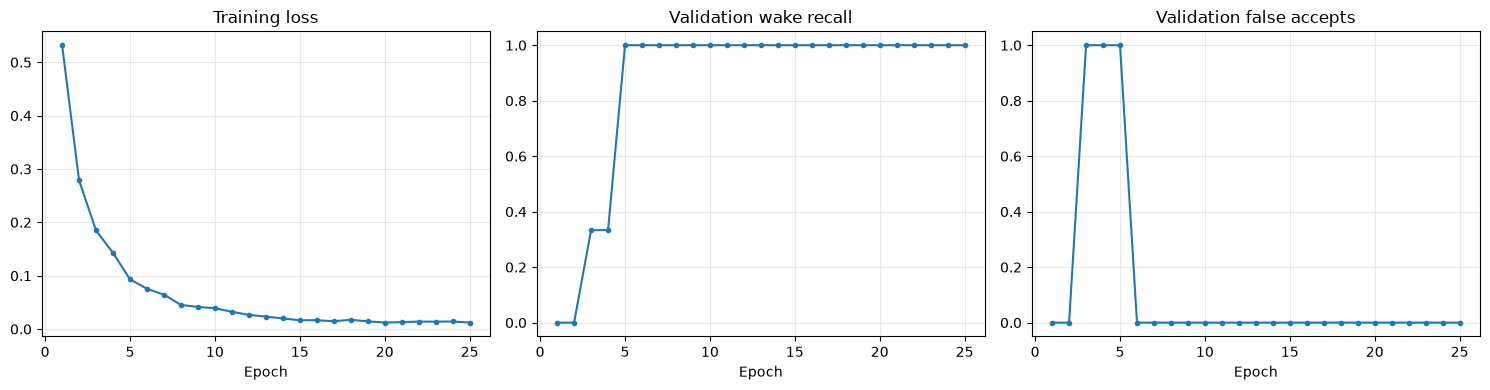

{
  "run": "antigrav-binary-wake-20260928-103823",
  "selected_validation_threshold": 0.9751818776130676,
  "validation": {
    "threshold_selected_on": "INT8 ONNX validation scores",
    "wake_clips": 3,
    "command_windows": 1818,
    "int8": {
      "wake_recall": 1.0,
      "false_count": 0,
      "false_budget": 1
    },
    "fp32_at_same_int8_selected_threshold": {
      "wake_recall": 0.3333333333333333,
      "false_count": 0
    },
    "fp32_checkpoint_selection_threshold": 0.9715114831924438,
    "fp32_checkpoint_selection_metrics": {
      "wake_recall": 1.0,
      "false_count": 0,
      "false_budget": 1
    }
  },
  "development_holdout_comparison": {
    "note": "One pass after training; Option B holdout artifacts have prior project evaluations and are not a pristine test. During planning their shapes were inspected before training but no test samples or labels were used in fit/threshold selection. Threshold and checkpoint were frozen using validation only; treat this a

In [3]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

run_dir = PROJECT_ROOT / 'runs' / candidate_metrics['run_name']
history = json.loads((run_dir / 'training_history.json').read_text(encoding='utf-8'))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = [row['epoch'] for row in history]
axes[0].plot(epochs, [row['train_loss'] for row in history], marker='o', ms=3)
axes[0].set_title('Training loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=.3)
axes[1].plot(epochs, [row['val_wake_recall'] for row in history], marker='o', ms=3)
axes[1].set_title('Validation wake recall'); axes[1].set_ylim(-.05, 1.05); axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=.3)
axes[2].plot(epochs, [row['val_false_wakes'] for row in history], marker='o', ms=3)
axes[2].set_title('Validation false accepts'); axes[2].set_xlabel('Epoch'); axes[2].grid(True, alpha=.3)
fig.tight_layout()
curve_path = run_dir / 'training_curves.png'
fig.savefig(curve_path, dpi=140, bbox_inches='tight')
plt.show()

report = {
    'run': candidate_metrics['run_name'],
    'selected_validation_threshold': candidate_metrics['validation_threshold'],
    'validation': candidate_metrics['validation'],
    'development_holdout_comparison': candidate_metrics['development_holdout_comparison'],
    'artifacts': candidate_metrics['artifacts'],
    'limitations': candidate_metrics['limitations'],
}
print(json.dumps(report, indent=2))
print(f'Run directory: {run_dir}')
print(f'Curve image: {curve_path}')

## Local wake sensitivity audit (no retraining)

This audit replays the selected INT8 ONNX model over the exact saved wake clips at five rolling-buffer alignments, saved command windows, and the available short background-noise excerpts. It does not fit weights or overwrite any artifact. The existing validation-selected threshold remains the release/provenance value. A lower **0.90 local sensitivity setting** is reported only as a live-test override: it still gives 3/3 validation wake clips and 0/1,818 validation command false accepts, while providing more score margin for quiet-mic testing. The Option B test windows were previously used and are exploratory; they are not a fresh test. The noise excerpt set is small and overlaps the training augmentation source, so it is not an independent false-activation-per-hour benchmark.

In [4]:
import json, sys
from pathlib import Path
import numpy as np
import onnxruntime as ort
import soundfile as sf

_here = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (_here, *_here.parents) if (p / 'train_binary_wake.py').is_file()), None)
if PROJECT_ROOT is None:
    PROJECT_ROOT = _here / 'AI 231' / 'Dumalaog_ME2 - Tiny Voice Command Model'
assert (PROJECT_ROOT / 'train_binary_wake.py').is_file(), f'Could not locate project from {_here}'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from train_binary_wake import fixed_context_windows, load_unique_human_wakes, probabilities, split_wake_groups
from tinyvcm_antigrav.config import SR, SAMPLES
from tinyvcm_antigrav.frontend import Frontend, fit_audio

run_dir = PROJECT_ROOT / 'runs' / 'antigrav-binary-wake-20260928-103823'
summary = json.loads((run_dir / 'export_summary.json').read_text(encoding='utf-8'))
selected_threshold = float(summary['validation_selected_threshold'])
local_threshold = 0.90
session = ort.InferenceSession(str(run_dir / 'models' / 'binary_wake_int8.onnx'), providers=['CPUExecutionProvider'])
frontend = Frontend()
rows, groups, _ = load_unique_human_wakes()
_, validation_groups, test_groups = split_wake_groups(groups)


def max_scores(items):
    result = []
    for item in items:
        windows = fixed_context_windows(item['audio'])
        features = np.stack([frontend(window) for window in windows]).astype(np.float32)
        result.append(float(probabilities(session, features)[:, 1].max()))
    return np.asarray(result, dtype=np.float32)

wake_scores = max_scores(groups)
val_wake_scores = max_scores(validation_groups)
test_wake_scores = max_scores(test_groups)
with np.load(PROJECT_ROOT / 'data' / 'option_b' / 'features_cache.npz', allow_pickle=False) as cache:
    val_command_scores = probabilities(session, cache['val_x'].astype(np.float32))[:, 1]
    test_command_scores = probabilities(session, cache['test_x'].astype(np.float32))[:, 1]
noise_features, noise_rms = [], []
for path in sorted((PROJECT_ROOT / 'data' / 'dataset' / '_background_noise_').glob('*.wav')):
    audio, rate = sf.read(str(path), dtype='float32')
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if rate != SR or not len(audio):
        continue
    audio = fit_audio(audio)
    noise_rms.append(float(np.sqrt(np.mean(audio ** 2))))
    noise_features.append(frontend(audio))
noise_scores = probabilities(session, np.stack(noise_features).astype(np.float32))[:, 1]

def assistant_stream_score(audio, interval, gate=0.006):
    """Replay assistant 150ms chunks, rolling buffer, RMS gate and interval."""
    stream = np.concatenate([np.asarray(audio, dtype=np.float32), np.zeros(int(2.5 * SR), dtype=np.float32)])
    buffer = np.zeros(SAMPLES, dtype=np.float32)
    chunk_n = int(0.15 * SR)
    last_inference = -1e6
    best_score = 0.0
    inference_calls = 0
    first_hit_sec = None
    for index, start in enumerate(range(0, len(stream), chunk_n)):
        chunk = stream[start:start + chunk_n]
        n = len(chunk)
        if n >= SAMPLES:
            buffer[:] = chunk[-SAMPLES:]
        else:
            buffer[:-n] = buffer[n:]
            buffer[-n:] = chunk
        now = (index + 1) * 0.15
        chunk_rms = float(np.sqrt(np.mean(chunk ** 2)))
        if chunk_rms > gate and now - last_inference > interval:
            feat = frontend(buffer)
            score = float(probabilities(session, feat[None].astype(np.float32))[0, 1])
            best_score = max(best_score, score)
            inference_calls += 1
            last_inference = now
            if score >= local_threshold and first_hit_sec is None:
                first_hit_sec = now
    return first_hit_sec, best_score, inference_calls

print('\nAssistant-style rolling stream replay (150ms microphone chunks; RMS gate 0.006):')
stream_summary = {}
for interval in (0.35, 0.12):
    wakes = [assistant_stream_score(item['audio'], interval) for item in groups]
    noise_rows = []
    for noise_path in sorted((PROJECT_ROOT / 'data' / 'dataset' / '_background_noise_').glob('*.wav')):
        noise_audio, noise_rate = sf.read(str(noise_path), dtype='float32')
        if noise_audio.ndim > 1:
            noise_audio = noise_audio.mean(axis=1)
        if noise_rate == SR and len(noise_audio):
            noise_rows.append(assistant_stream_score(noise_audio, interval))
    wake_hits = sum(hit is not None for hit, _, _ in wakes)
    noise_false = sum(score >= local_threshold for _, score, _ in noise_rows)
    stream_summary[str(interval)] = {
        'wake_hits': f'{wake_hits}/{len(wakes)}',
        'noise_false_accepts': f'{noise_false}/{len(noise_rows)}',
        'mean_wake_inferences': round(float(np.mean([n for _, _, n in wakes])), 2),
        'max_noise_score': round(max((score for _, score, _ in noise_rows), default=0.0), 6),
    }
    print(f'interval={interval:.2f}s: wake={wake_hits}/{len(wakes)}, noise false accepts={noise_false}/{len(noise_rows)}, mean wake inference calls={stream_summary[str(interval)]["mean_wake_inferences"]}, max noise score={stream_summary[str(interval)]["max_noise_score"]:.6f}')
print('The 0.12s interval matches mic chunk cadence and is the local trial setting. Replay results are not live microphone results.')

sources = [
    ('All saved real wake recordings', wake_scores, True),
    ('Human wake validation split', val_wake_scores, True),
    ('Human wake exploratory split', test_wake_scores, True),
    ('Option B command validation windows', val_command_scores, False),
    ('Option B command prior-use exploratory windows', test_command_scores, False),
    ('Short background-noise excerpts', noise_scores, False),
]
print(f'INT8 ONNX: {summary["int8_onnx"]["size_bytes"]:,} bytes; selected validation threshold={selected_threshold:.6f}; local sensitivity override={local_threshold:.2f}')
print(f'Wake partitions: all={len(wake_scores)}; validation={len(val_wake_scores)}; exploratory={len(test_wake_scores)}; speaker=person-01 only')
print(f'Background excerpts: {len(noise_scores)}; RMS max={max(noise_rms):.4f}; count over VAD 0.012={sum(x > 0.012 for x in noise_rms)}/{len(noise_rms)}')
print('\n' + f'{"Source":53} {"N":>5} {"Hits/FAs @ selected":>21} {"Hits/FAs @ 0.90":>19} {"Hits/FAs @ 0.60":>19}')
for name, scores, positive in sources:
    values = [int(np.sum(scores >= threshold)) for threshold in (selected_threshold, local_threshold, 0.60)]
    ratios = [f'{count}/{len(scores)}' for count in values]
    print(f'{name:53} {len(scores):5d} {ratios[0]:>21} {ratios[1]:>19} {ratios[2]:>19}')
print('\nInterpretation: wake rows report hits; command/noise rows report false accepts. The 0.90 override improves margin for a local mic check but has not been validated on continuous room audio or unseen speakers.')


Assistant-style rolling stream replay (150ms microphone chunks; RMS gate 0.006):
interval=0.35s: wake=14/16, noise false accepts=0/90, mean wake inference calls=2.0, max noise score=0.776740
interval=0.12s: wake=16/16, noise false accepts=0/90, mean wake inference calls=6.0, max noise score=0.776740
The 0.12s interval matches mic chunk cadence and is the local trial setting. Replay results are not live microphone results.
INT8 ONNX: 37,425 bytes; selected validation threshold=0.975182; local sensitivity override=0.90
Wake partitions: all=16; validation=3; exploratory=3; speaker=person-01 only
Background excerpts: 90; RMS max=0.0319; count over VAD 0.012=60/90

Source                                                    N   Hits/FAs @ selected     Hits/FAs @ 0.90     Hits/FAs @ 0.60
All saved real wake recordings                           16                 16/16               16/16               16/16
Human wake validation split                               3                   3/3     